<a href="https://colab.research.google.com/github/MohammadAburub93/Python-Data-Science-Practice/blob/main/Multivariable%20Regression/Multivariable_Regression_and_Valuation_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src=https://i.imgur.com/WKQ0nH2.jpg height=350>

# Boston Massachusetts House Price Estimate


In [105]:
#%pip install --upgrade plotly

###  Import Statements


In [106]:
import pandas as pd
import numpy as np

import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Notebook Presentation

In [107]:
pd.options.display.float_format = '{:,.2f}'.format

# Load the Data



In [108]:
data = pd.read_csv('boston.csv', index_col=0)

# Preliminary Data Exploration 🔎


In [109]:
data.shape

(506, 14)

In [110]:
print(f'The dataset has {data.shape[0]} rows and {data.shape[1]} columns')

The dataset has 506 rows and 14 columns


In [111]:
data.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'PRICE'],
      dtype='object')

In [112]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(14)
memory usage: 59.3 KB


## Data Cleaning - Check for Missing Values and Duplicates

In [113]:
print(f'Any NaN values? {data.isna().values.any()}')

Any NaN values? False


In [114]:
print(f'Any duplicated values? {data.duplicated().values.any()}')

Any duplicated values? False


In [115]:
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.01,18.00,2.31,0.00,0.54,6.58,65.20,4.09,1.00,296.00,15.30,396.90,4.98,24.00
1,0.03,0.00,7.07,0.00,0.47,6.42,78.90,4.97,2.00,242.00,17.80,396.90,9.14,21.60
2,0.03,0.00,7.07,0.00,0.47,7.18,61.10,4.97,2.00,242.00,17.80,392.83,4.03,34.70
3,0.03,0.00,2.18,0.00,0.46,7.00,45.80,6.06,3.00,222.00,18.70,394.63,2.94,33.40
4,0.07,0.00,2.18,0.00,0.46,7.15,54.20,6.06,3.00,222.00,18.70,396.90,5.33,36.20


## Descriptive Statistics



In [116]:
data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.39,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.23,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


## Visualise the Features



#### House Prices 💰

<Figure size 1280x960 with 0 Axes>

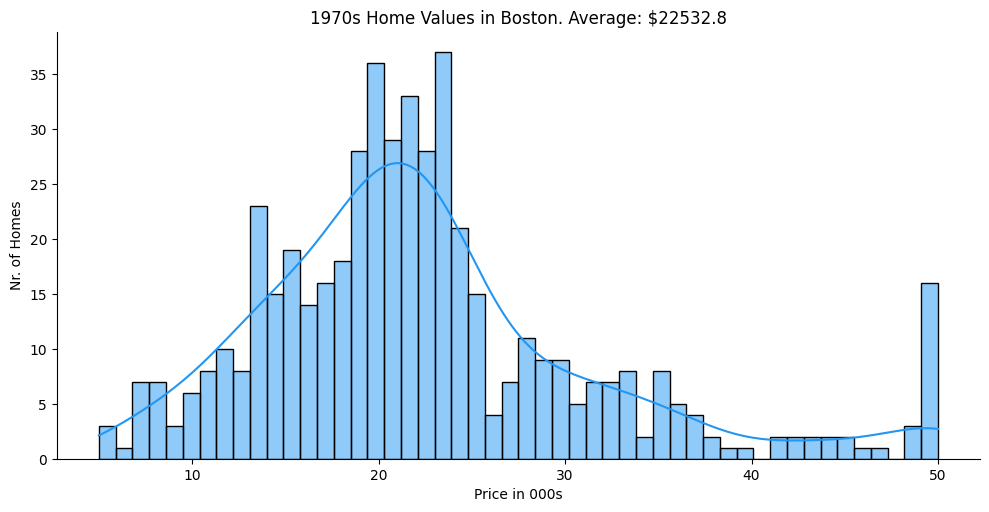

In [117]:
plt.figure(dpi=200)
sns.displot(data,
            x='PRICE',
            kde=True,
            aspect=2,
            color='#2196f3',
            bins=50)

plt.title(f'1970s Home Values in Boston. Average: ${(1000*data.PRICE.mean()):.6}')
plt.xlabel('Price in 000s')
plt.ylabel('Nr. of Homes')
plt.show()

#### Distance to Employment - Length of Commute 🚗

<Figure size 1280x960 with 0 Axes>

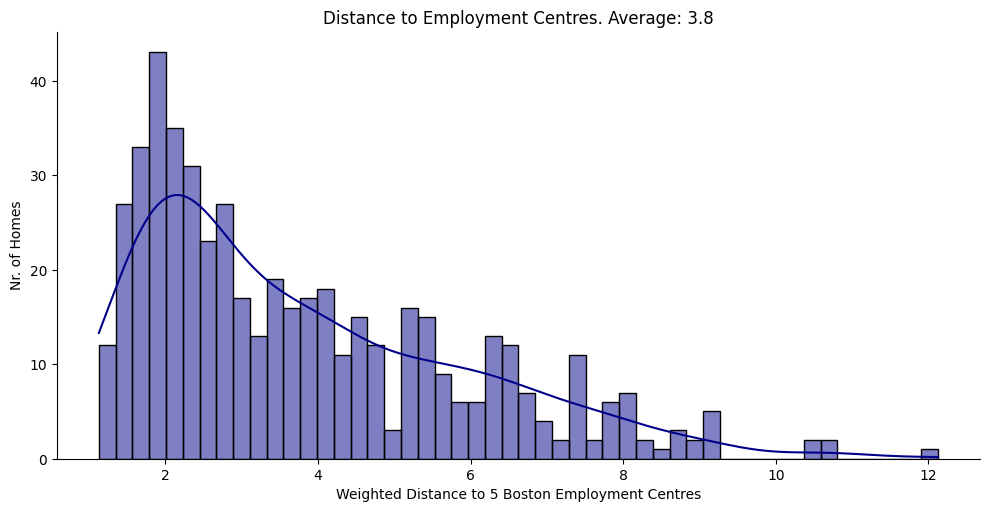

In [118]:
plt.figure(dpi=200)
sns.displot(data,
            x='DIS',
            kde=True,
            aspect=2,
            color='darkblue',
            bins=50)

plt.title(f'Distance to Employment Centres. Average: {(data.DIS.mean()):.2}')
plt.xlabel('Weighted Distance to 5 Boston Employment Centres')
plt.ylabel('Nr. of Homes')
plt.show()

#### Number of Rooms

<Figure size 1280x960 with 0 Axes>

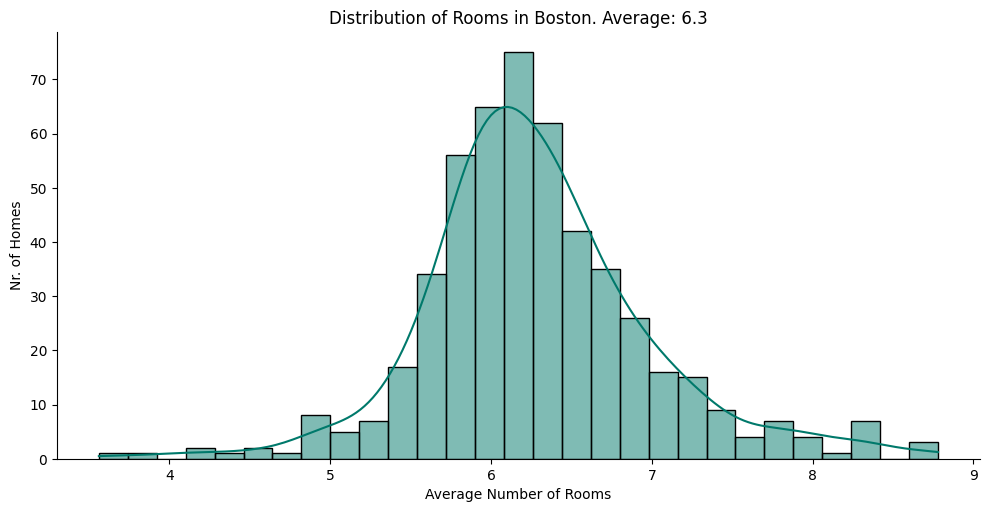

In [119]:
plt.figure(dpi=200)
sns.displot(data,
            x='RM',
            kde=True,
            aspect=2,
            color='#00796b'
            )
plt.title(f'Distribution of Rooms in Boston. Average: {data.RM.mean():.2}')
plt.xlabel('Average Number of Rooms')
plt.ylabel('Nr. of Homes')

plt.show()

#### Access to Highways 🛣

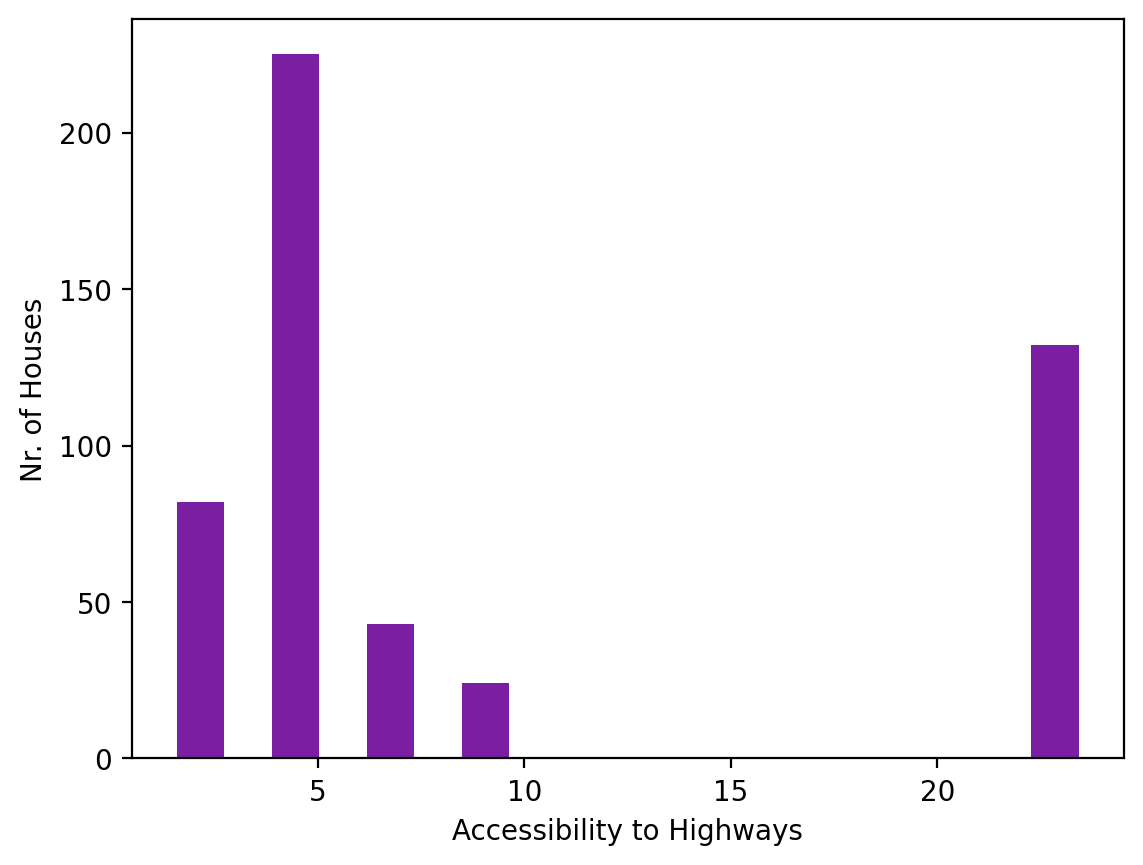

In [120]:
plt.figure(dpi=200)
plt.hist(data.RAD,
            color='#7b1fa2',
            rwidth=0.5
            )
plt.xlabel('Accessibility to Highways')
plt.ylabel('Nr. of Houses')

plt.show()

#### Next to the River? ⛵️



In [121]:
river_count = data.groupby(by='CHAS')['CHAS'].count()

In [122]:
bar = px.bar(x=['No', 'Yes'],
             y=river_count.values,
             color=river_count.values,
            color_continuous_scale=px.colors.sequential.haline,
             title='Next to Charles Revir?')

bar.update_layout(
    xaxis_title='Property Located Next to Revir?',
    yaxis_title='Number of Homes',
    coloraxis_showscale=False,
)

bar.show()

<img src=https://i.imgur.com/b5UaBal.jpg height=350>

# Understand the Relationships in the Data

### Run a Pair Plot



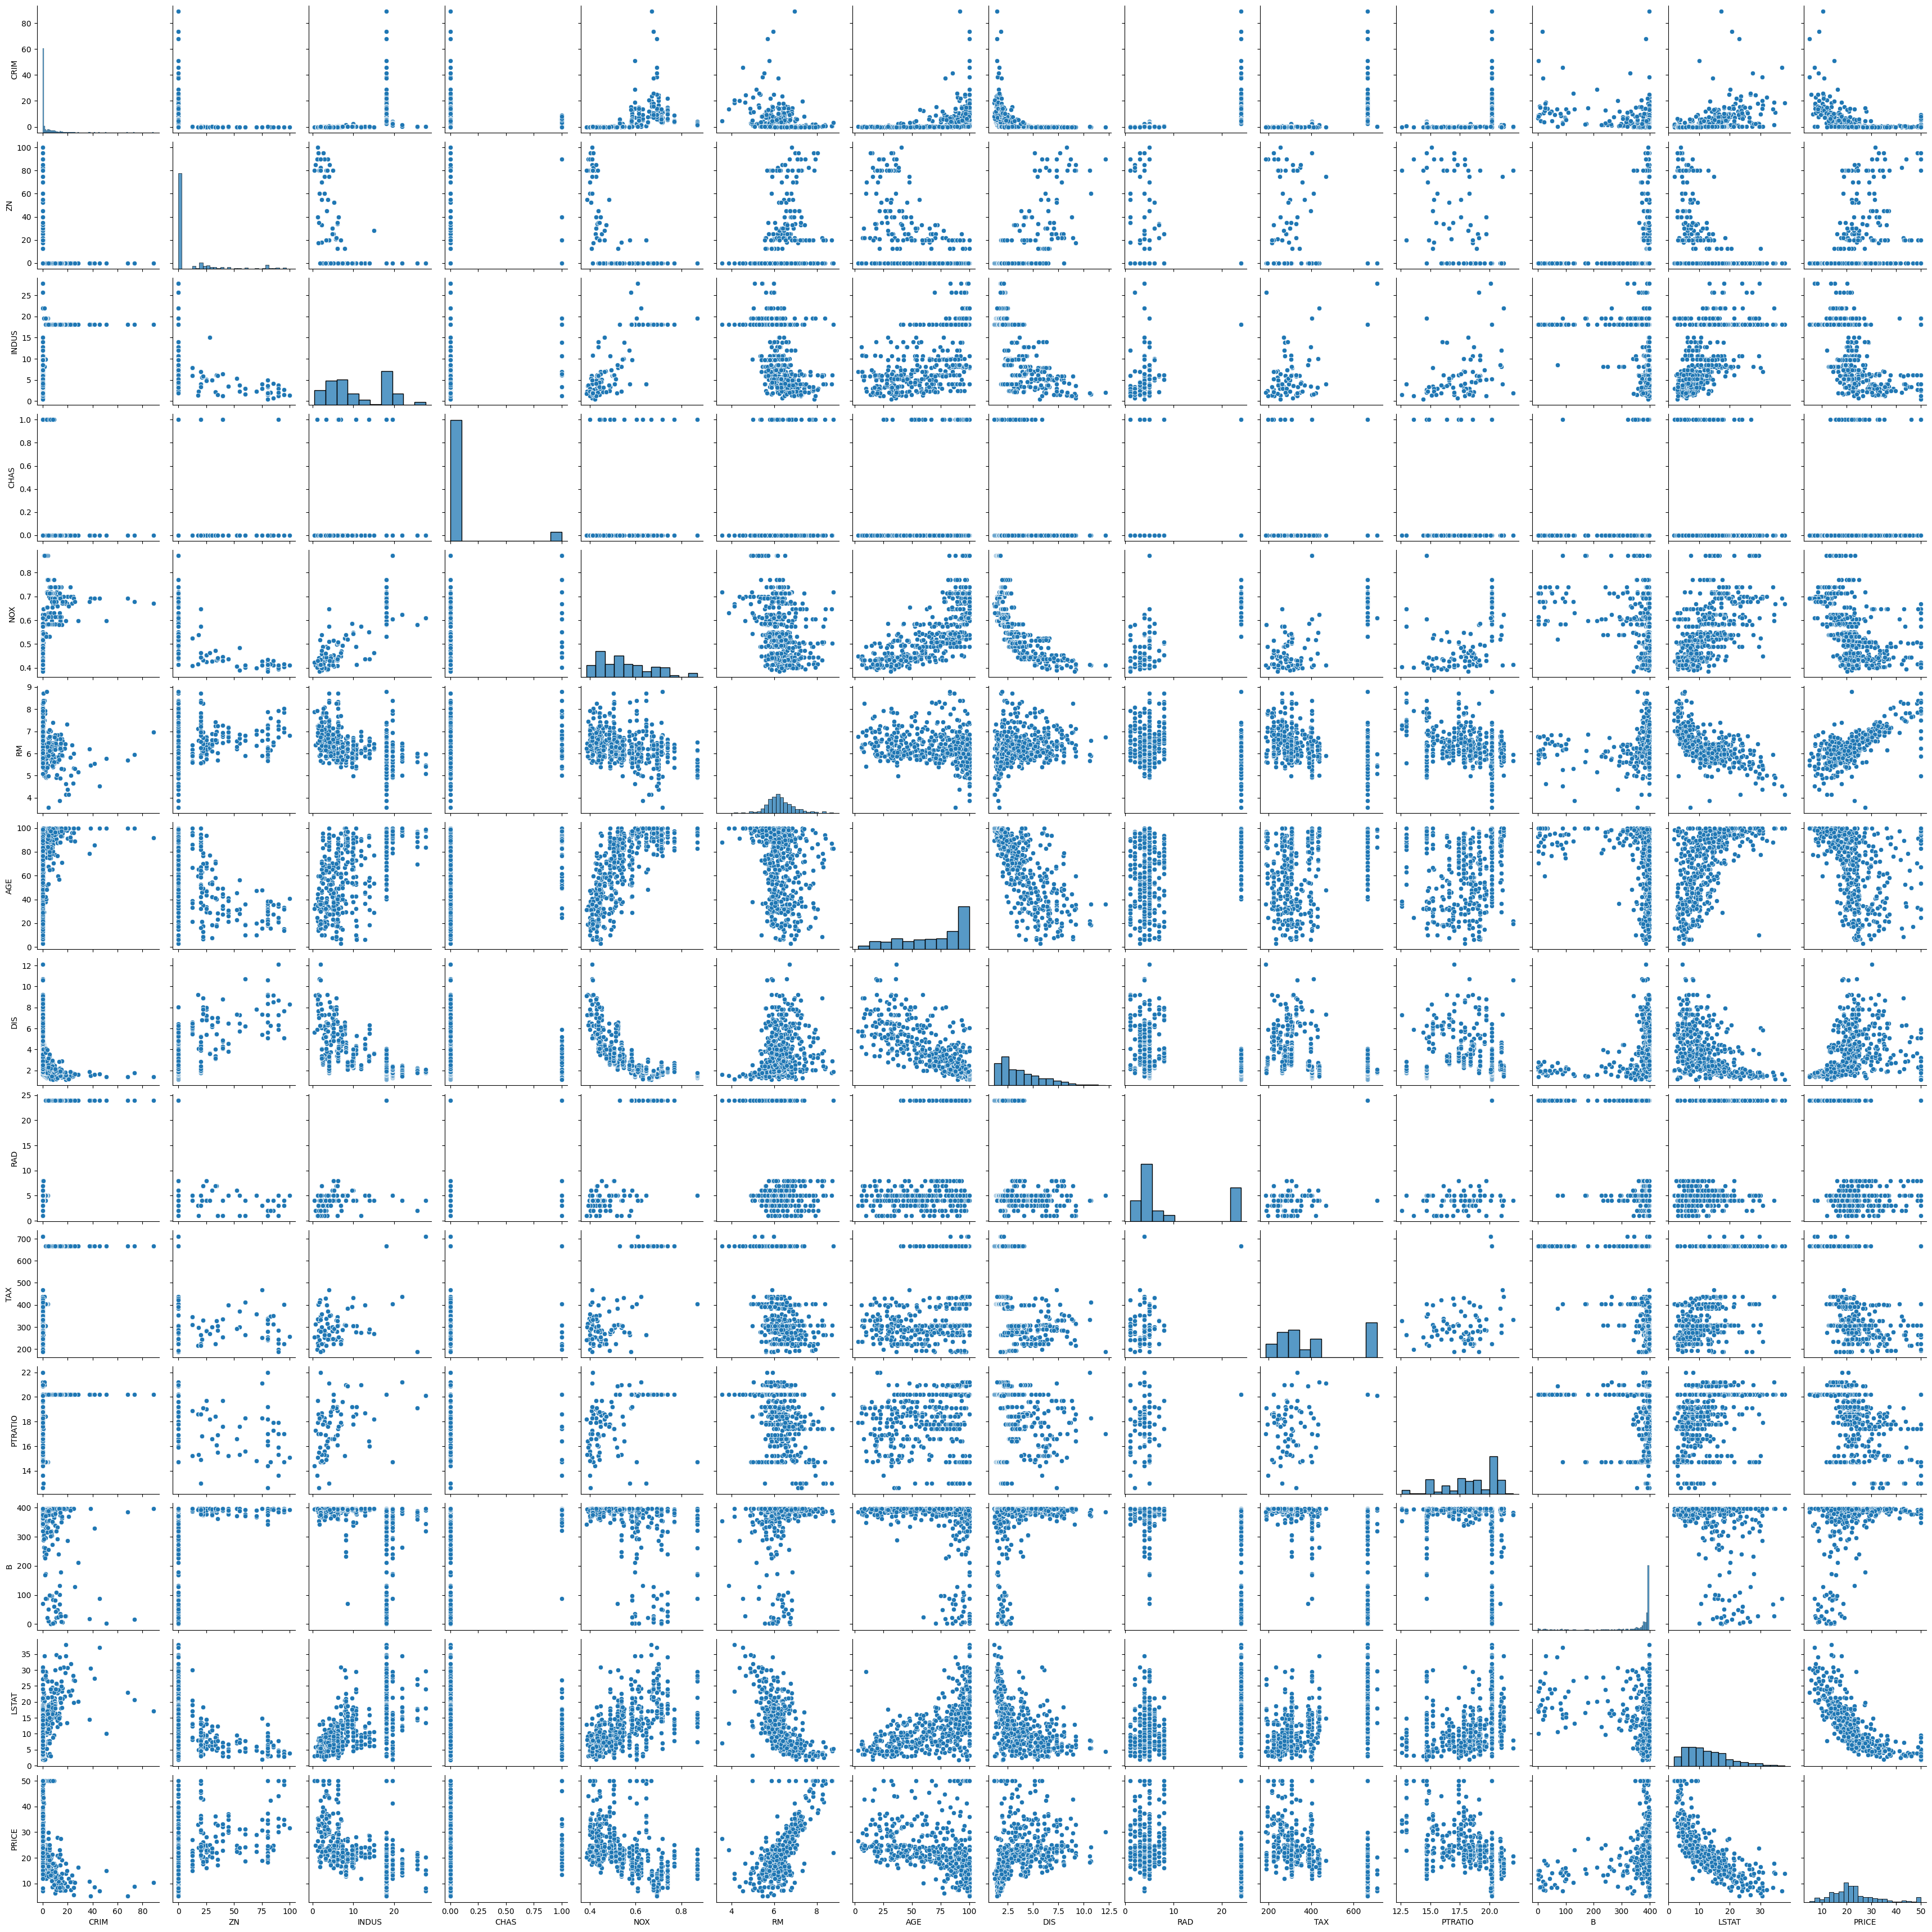

In [123]:
sns.pairplot(data)

#### Distance from Employment vs. Pollution



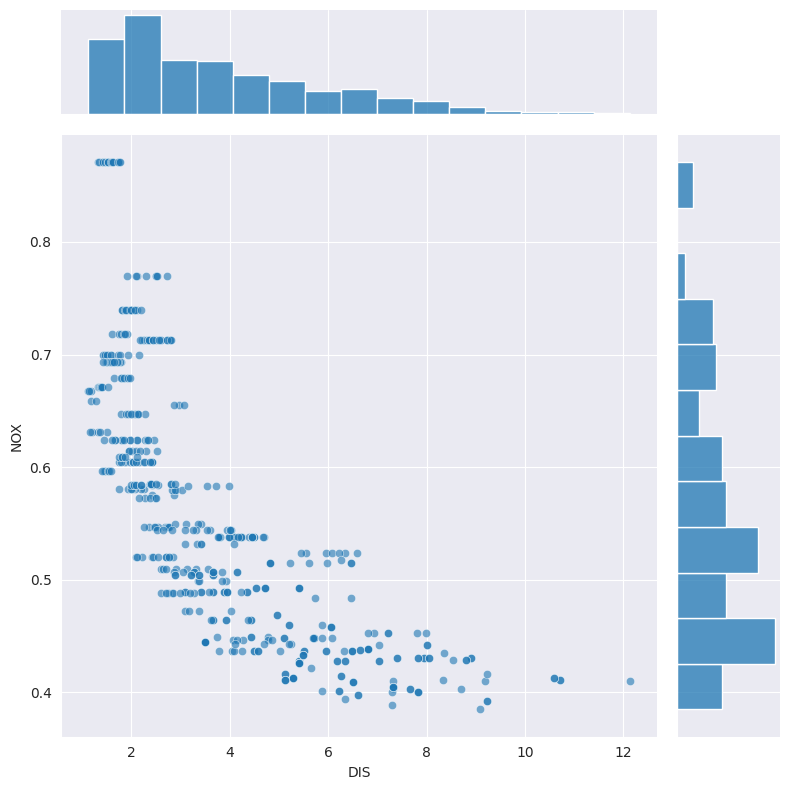

In [124]:
with sns.axes_style('darkgrid'):
  sns.jointplot(data,
              x='DIS',
              height=8,
              kind='scatter',
              y='NOX',
              joint_kws={'alpha':0.6},
              )
  plt.show()

#### Proportion of Non-Retail Industry 🏭🏭🏭 versus Pollution



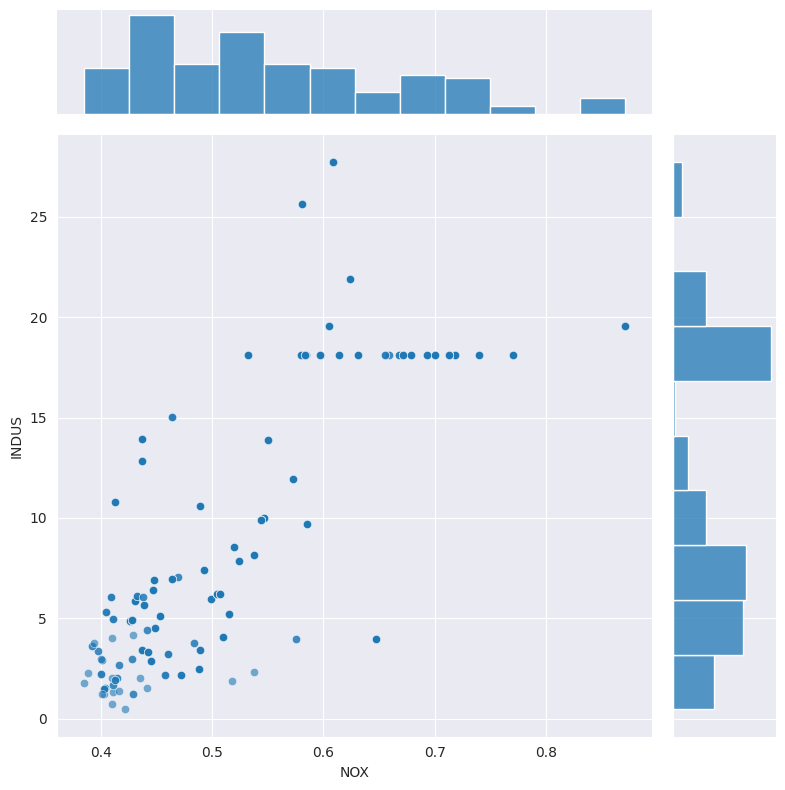

In [125]:
with sns.axes_style('darkgrid'):
  sns.jointplot(data,
              x='NOX',
              height=8,
              kind='scatter',
              y='INDUS',
              joint_kws={'alpha':0.6},
              )
  plt.show()

#### % of Lower Income Population vs Average Number of Rooms


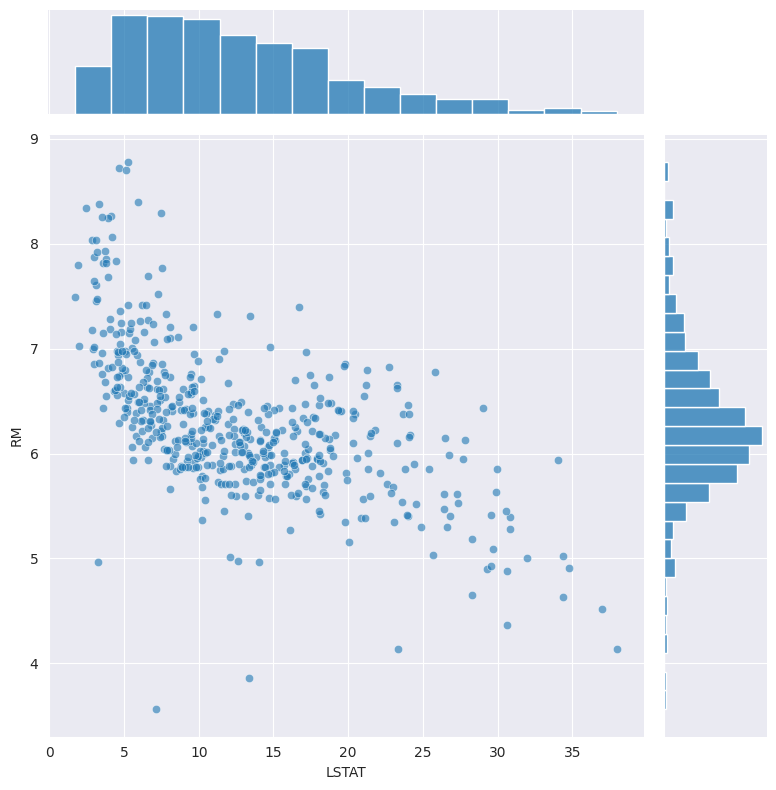

In [126]:
with sns.axes_style('darkgrid'):
  sns.jointplot(data,
              x='LSTAT',
              height=8,
              kind='scatter',
              y='RM',
              joint_kws={'alpha':0.6},
              )
  plt.show()

#### % of Lower Income Population versus Home Price



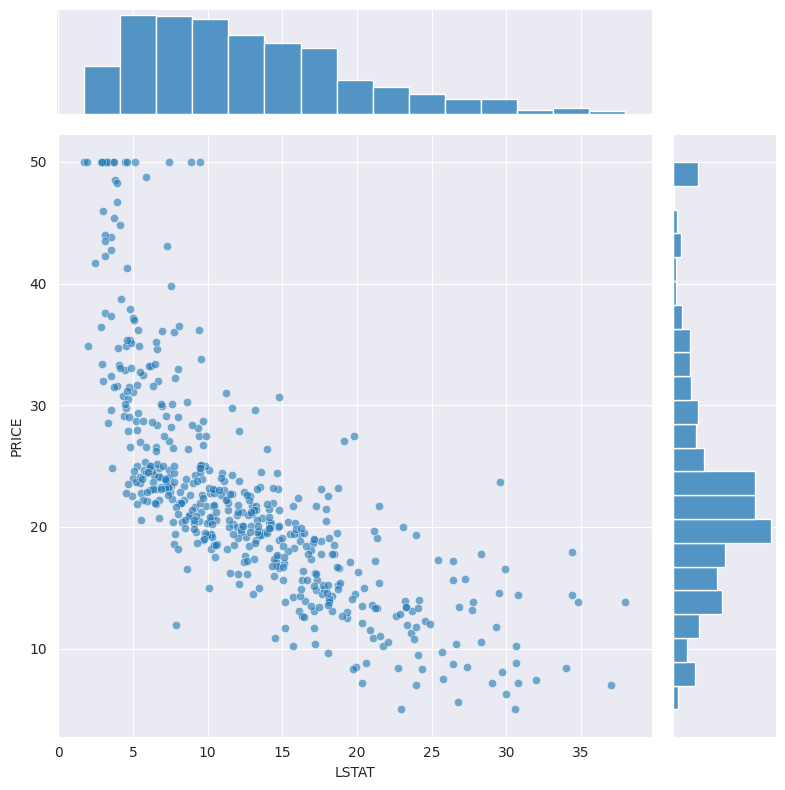

In [127]:
with sns.axes_style('darkgrid'):
  sns.jointplot(data,
              x='LSTAT',
              height=8,
              kind='scatter',
              y='PRICE',
              joint_kws={'alpha':0.6},
              )
  plt.show()

#### Number of Rooms versus Home Value



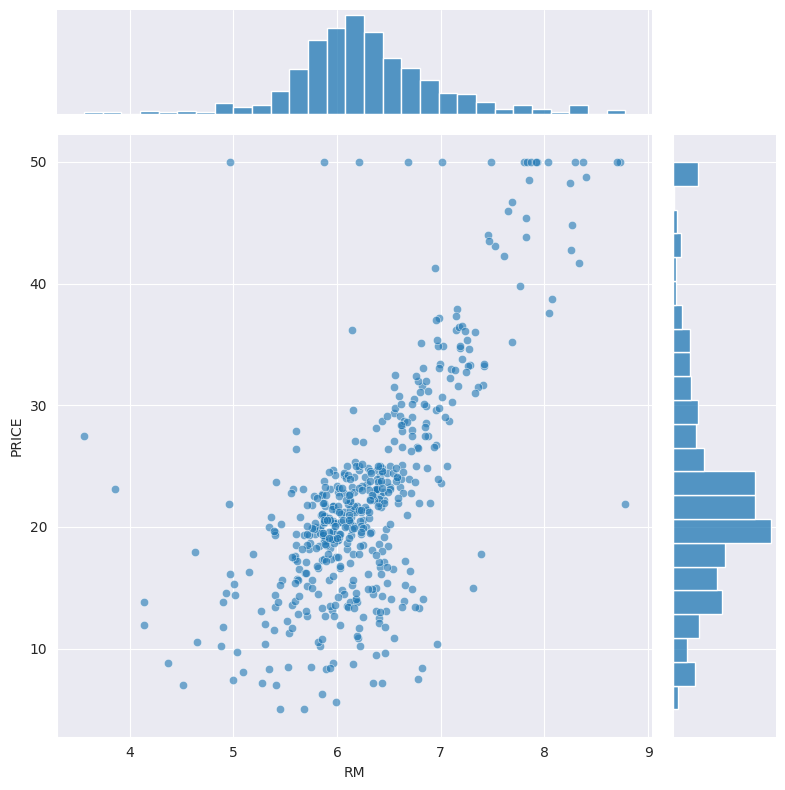

In [128]:
with sns.axes_style('darkgrid'):
  sns.jointplot(data,
              x='RM',
              height=8,
              kind='scatter',
              y='PRICE',
              joint_kws={'alpha':0.6},
              )
  plt.show()

# Split Training & Test Dataset




In [129]:
X = data.drop('PRICE', axis=1)
y = data["PRICE"]

In [130]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=10)

# Multivariable Regression



### Run Your First Regression



In [131]:
model = LinearRegression()

In [132]:
model.fit(X_train,y_train)

LinearRegression()

In [133]:
rsquared = model.score(X_train,y_train)
print(f'Training data r-squared: {rsquared:.2}')

Training data r-squared: 0.75


### Evaluate the Coefficients of the Model



In [134]:
model.intercept_

np.float64(36.53305138282431)

In [135]:
regr_coef = pd.DataFrame(data=model.coef_, index=X_train.columns, columns=['Coefficient'])
regr_coef

,Coefficient
CRIM,-0.13
ZN,0.06
INDUS,-0.01
CHAS,1.97
NOX,-16.27
RM,3.11
AGE,0.02
DIS,-1.48
RAD,0.30
TAX,-0.01


In [136]:
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.01,18.00,2.31,0.00,0.54,6.58,65.20,4.09,1.00,296.00,15.30,396.90,4.98,24.00
1,0.03,0.00,7.07,0.00,0.47,6.42,78.90,4.97,2.00,242.00,17.80,396.90,9.14,21.60
2,0.03,0.00,7.07,0.00,0.47,7.18,61.10,4.97,2.00,242.00,17.80,392.83,4.03,34.70
3,0.03,0.00,2.18,0.00,0.46,7.00,45.80,6.06,3.00,222.00,18.70,394.63,2.94,33.40
4,0.07,0.00,2.18,0.00,0.46,7.15,54.20,6.06,3.00,222.00,18.70,396.90,5.33,36.20


### Analyse the Estimated Values & Regression Residuals


In [137]:
predicted_values = model.predict(X_train)
residuals = (y_train - predicted_values)

<>:4: SyntaxWarning:

invalid escape sequence '\h'

<>:6: SyntaxWarning:

invalid escape sequence '\h'

<>:13: SyntaxWarning:

invalid escape sequence '\h'

<>:4: SyntaxWarning:

invalid escape sequence '\h'

<>:6: SyntaxWarning:

invalid escape sequence '\h'

<>:13: SyntaxWarning:

invalid escape sequence '\h'

/tmp/ipython-input-232/2960761161.py:4: SyntaxWarning:

invalid escape sequence '\h'

/tmp/ipython-input-232/2960761161.py:6: SyntaxWarning:

invalid escape sequence '\h'

/tmp/ipython-input-232/2960761161.py:13: SyntaxWarning:

invalid escape sequence '\h'



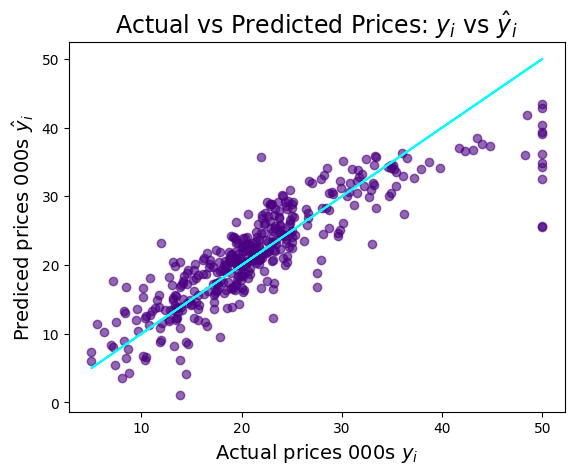

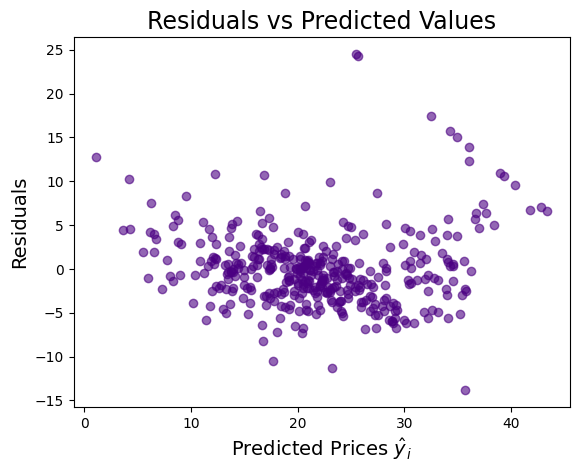

In [138]:
plt.figure(dpi=100)
plt.scatter(x=y_train, y=predicted_values, c='indigo', alpha=0.6)
plt.plot(y_train, y_train, color='cyan')
plt.title(f'Actual vs Predicted Prices: $y _i$ vs $\hat y_i$', fontsize=17)
plt.xlabel('Actual prices 000s $y _i$', fontsize=14)
plt.ylabel('Prediced prices 000s $\hat y _i$', fontsize=14)
plt.show()


plt.figure(dpi=100)
plt.scatter(x=predicted_values, y=residuals, c='indigo', alpha=0.6)
plt.title('Residuals vs Predicted Values', fontsize=17)
plt.xlabel('Predicted Prices $\hat y _i$', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.show()

In [139]:
res_mean = round(residuals.mean(), 2)
res_skew = round(residuals.skew(), 2)

In [140]:
res_mean

np.float64(0.0)

In [141]:
res_skew

np.float64(1.46)

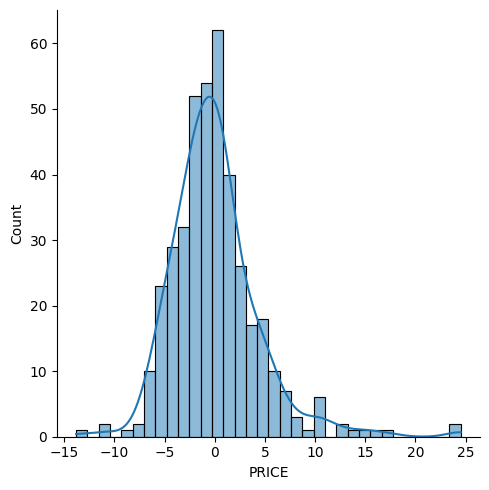

In [142]:
sns.displot(x=residuals, kde=True)

### Data Transformations for a Better Fit




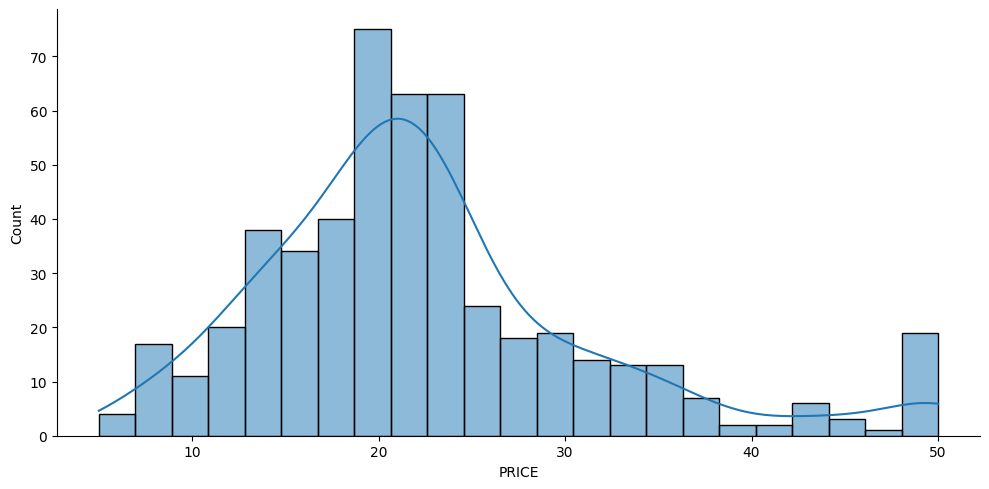

In [143]:
sns.displot(data, x='PRICE', kde=True, aspect=2)

In [144]:
data.PRICE.skew()

np.float64(1.1080984082549072)

In [145]:
log_prices = np.log(data.PRICE)

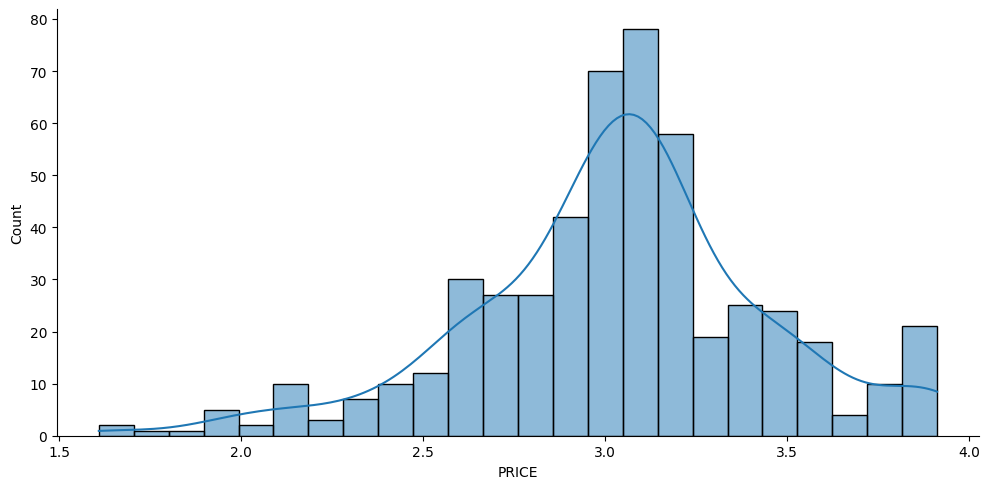

In [146]:
sns.displot(x=log_prices, kde=True, aspect=2)

In [147]:
log_prices.skew()

np.float64(-0.33032129530987864)

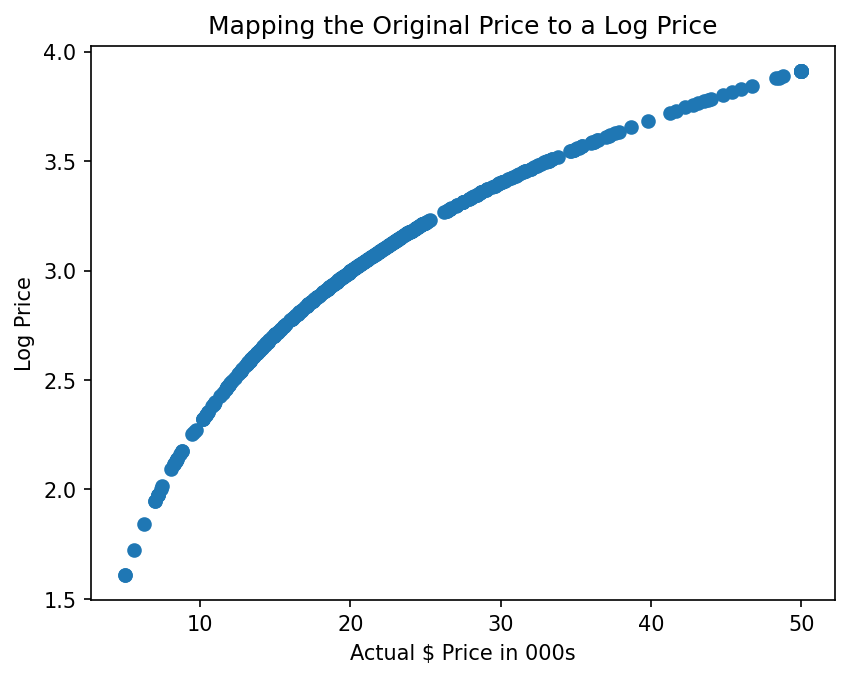

In [148]:
plt.figure(dpi=150)
plt.scatter(data.PRICE, np.log(data.PRICE))

plt.title('Mapping the Original Price to a Log Price')
plt.ylabel('Log Price')
plt.xlabel('Actual $ Price in 000s')
plt.show()

## Regression using Log Prices



In [149]:
log_X_train, X_test, log_y_train, y_test = train_test_split(X, log_prices, train_size=0.8, random_state=10)

In [150]:
log_model = LinearRegression()

In [151]:
log_model.fit(X_train,log_y_train)

LinearRegression()

In [152]:
log_rsquared = log_model.score(log_X_train, log_y_train)

## Evaluating Coefficients with Log Prices



In [153]:
log_model.coef_

array([-1.06717261e-02,  1.57929102e-03,  2.02989827e-03,  8.03305301e-02,
       -7.04068057e-01,  7.34044072e-02,  7.63301755e-04, -4.76332789e-02,
        1.45651350e-02, -6.44998303e-04, -3.47947628e-02,  5.15896157e-04,
       -3.13900565e-02])

In [154]:
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.01,18.00,2.31,0.00,0.54,6.58,65.20,4.09,1.00,296.00,15.30,396.90,4.98,24.00
1,0.03,0.00,7.07,0.00,0.47,6.42,78.90,4.97,2.00,242.00,17.80,396.90,9.14,21.60
2,0.03,0.00,7.07,0.00,0.47,7.18,61.10,4.97,2.00,242.00,17.80,392.83,4.03,34.70
3,0.03,0.00,2.18,0.00,0.46,7.00,45.80,6.06,3.00,222.00,18.70,394.63,2.94,33.40
4,0.07,0.00,2.18,0.00,0.46,7.15,54.20,6.06,3.00,222.00,18.70,396.90,5.33,36.20


## Regression with Log Prices & Residual Plots



In [155]:
log_predicted_values = log_model.predict(log_X_train)
log_residuals = (y_train - log_predicted_values)

<>:4: SyntaxWarning:

invalid escape sequence '\h'

<>:6: SyntaxWarning:

invalid escape sequence '\h'

<>:12: SyntaxWarning:

invalid escape sequence '\h'

<>:14: SyntaxWarning:

invalid escape sequence '\h'

<>:20: SyntaxWarning:

invalid escape sequence '\h'

<>:27: SyntaxWarning:

invalid escape sequence '\h'

<>:4: SyntaxWarning:

invalid escape sequence '\h'

<>:6: SyntaxWarning:

invalid escape sequence '\h'

<>:12: SyntaxWarning:

invalid escape sequence '\h'

<>:14: SyntaxWarning:

invalid escape sequence '\h'

<>:20: SyntaxWarning:

invalid escape sequence '\h'

<>:27: SyntaxWarning:

invalid escape sequence '\h'

/tmp/ipython-input-232/54834713.py:4: SyntaxWarning:

invalid escape sequence '\h'

/tmp/ipython-input-232/54834713.py:6: SyntaxWarning:

invalid escape sequence '\h'

/tmp/ipython-input-232/54834713.py:12: SyntaxWarning:

invalid escape sequence '\h'

/tmp/ipython-input-232/54834713.py:14: SyntaxWarning:

invalid escape sequence '\h'

/tmp/ipython-input-232/5483471

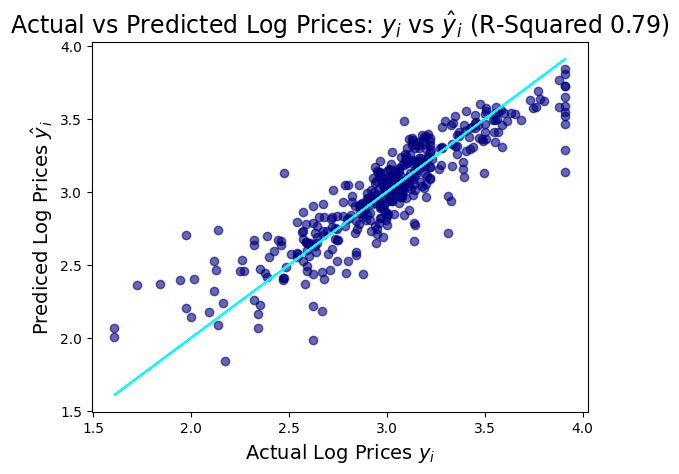

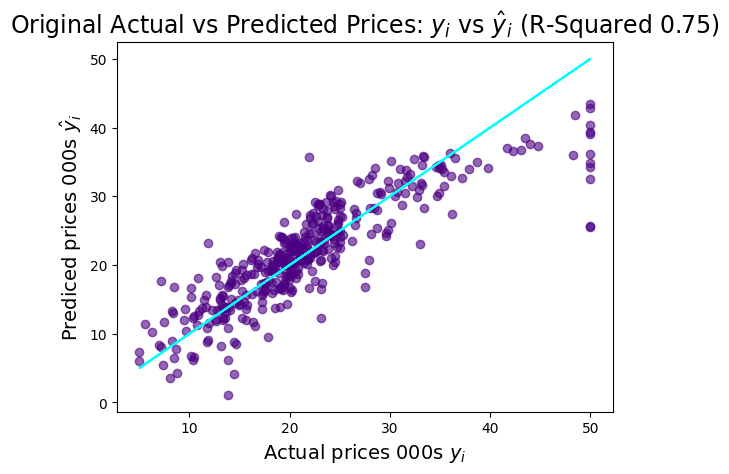

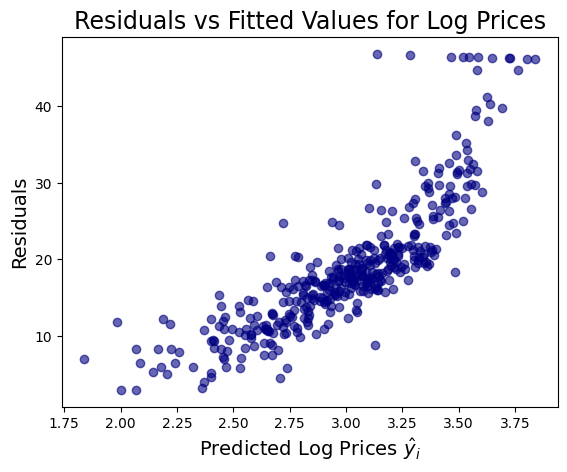

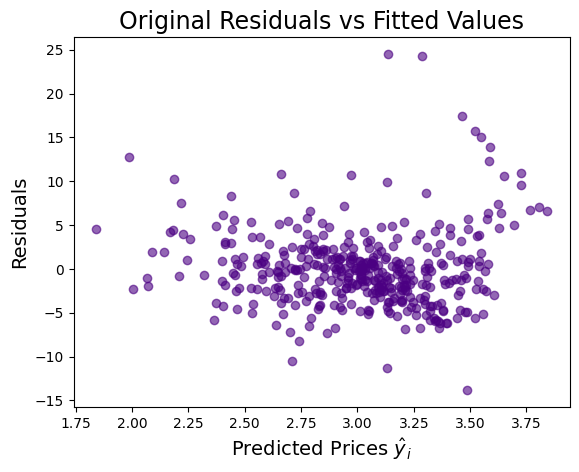

In [156]:
# Graph of Actual vs. Predicted Log Prices
plt.scatter(x=log_y_train, y=log_predicted_values, c='navy', alpha=0.6)
plt.plot(log_y_train, log_y_train, color='cyan')
plt.title(f'Actual vs Predicted Log Prices: $y _i$ vs $\hat y_i$ (R-Squared {log_rsquared:.2})', fontsize=17)
plt.xlabel('Actual Log Prices $y _i$', fontsize=14)
plt.ylabel('Prediced Log Prices $\hat y _i$', fontsize=14)
plt.show()

# Original Regression of Actual vs. Predicted Prices
plt.scatter(x=y_train, y=predicted_values, c='indigo', alpha=0.6)
plt.plot(y_train, y_train, color='cyan')
plt.title(f'Original Actual vs Predicted Prices: $y _i$ vs $\hat y_i$ (R-Squared {rsquared:.3})', fontsize=17)
plt.xlabel('Actual prices 000s $y _i$', fontsize=14)
plt.ylabel('Prediced prices 000s $\hat y _i$', fontsize=14)
plt.show()

# Residuals vs Predicted values (Log prices)
plt.scatter(x=log_predicted_values, y=log_residuals, c='navy', alpha=0.6)
plt.title('Residuals vs Fitted Values for Log Prices', fontsize=17)
plt.xlabel('Predicted Log Prices $\hat y _i$', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.show()

# Residuals vs Predicted values
plt.scatter(x=log_predicted_values, y=residuals, c='indigo', alpha=0.6)
plt.title('Original Residuals vs Fitted Values', fontsize=17)
plt.xlabel('Predicted Prices $\hat y _i$', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.show()

**Challenge**:



In [157]:
log_residuals.mean()

np.float64(18.83623830781599)

In [158]:
log_residuals.skew()

np.float64(1.2051348482993771)

# Compare Out of Sample Performance



In [159]:
model.score(X_train, y_train)

0.750121534530608

In [160]:
log_model.score(log_X_train, log_y_train)

0.7930234826697584

# Predict a Property's Value using the Regression Coefficients



In [161]:
features = data.drop(['PRICE'], axis=1)
average_vals = features.mean().values
property_stats = pd.DataFrame(data=average_vals.reshape(1, len(features.columns)),
                              columns=features.columns)
property_stats

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65


In [162]:
# Make prediction
log_estimate = log_model.predict(property_stats)[0]
print(f'The log price estimate is ${log_estimate:.3}')

dollar_est = np.exp(log_estimate) * 1000
print(f'The property is estimated to be worth ${dollar_est:.6}')

The log price estimate is $3.03
The property is estimated to be worth $20703.2


In [163]:
next_to_river = True
nr_rooms = 8
students_per_classroom = 20
distance_to_town = 5
pollution = data.NOX.quantile(q=0.75) # high
amount_of_poverty =  data.LSTAT.quantile(q=0.25) # low

In [164]:
property_stats['RM'] = nr_rooms
property_stats['PTRATIO'] = students_per_classroom
property_stats['DIS'] = distance_to_town

if next_to_river:
    property_stats['CHAS'] = 1
else:
    property_stats['CHAS'] = 0

property_stats['NOX'] = pollution
property_stats['LSTAT'] = amount_of_poverty

In [165]:
log_estimate = log_model.predict(property_stats)[0]
print(f'The log price estimate is ${log_estimate:.3}')

# Convert Log Prices to Acutal Dollar Values
dollar_est = np.e**log_estimate * 1000
print(f'The property is estimated to be worth ${dollar_est:.6}')

The log price estimate is $3.25
The property is estimated to be worth $25792.0
